# 55 - Kaiming and Xavier Initialization

**Section:** Weight Initialization | **Prereqs:** `Weight Initialization/CodeChallenge_IndenticallyRandomWeights.ipynb` | **Next:** `Weight Initialization/CodeChallenge_KaimingVsXaivier.ipynb`

Random is necessary but not sufficient - the *scale* of the randomness decides
whether a deep network trains at all.

**The problem.** Each layer multiplies its input by a weight matrix. If the
weights are slightly too large, activations grow layer by layer and explode; if
slightly too small, they shrink to nothing. Either way, gradients on the way back
do the same thing, and a deep network stops learning.

**The fix: scale the initial variance by the layer's fan-in.**

| Scheme | Variance | Designed for |
|---|---|---|
| **Xavier / Glorot** | `2/(fan_in + fan_out)` | tanh, sigmoid (symmetric activations) |
| **Kaiming / He** | `2/fan_in` | ReLU - the extra factor of 2 compensates for ReLU zeroing half the inputs |

**PyTorch's default is Kaiming-uniform**, bounded by `+/- sqrt(1/fan_in)` - and
this notebook verifies that empirically by comparing the observed weight range
against `sqrt(1/100)`. Since almost everything uses ReLU, the default is usually
already correct, which is why you rarely see explicit initialisation code.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

In [40]:
# 100 -> 100 -> 100 -> 100 -> 2. Uniform layer widths make the fan-in identical
# everywhere, which is what lets the check below be a single number.
class classfier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(100,100)

    self.fc1 = nn.Linear(100,100)
    self.fc2 = nn.Linear(100,100)

    self.output_layer = nn.Linear(100,2)


  def forward(self,x):

    x = F.relu(self.input_layer(x))
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [41]:
model = classfier()
print(model)

classfier(
  (input_layer): Linear(in_features=100, out_features=100, bias=True)
  (fc1): Linear(in_features=100, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (output_layer): Linear(in_features=100, out_features=2, bias=True)
)


In [42]:
# Collect all weights and all biases into two flat arrays.
all_weights = np.array([])
all_biases = np.array([])

for pname, y in model.named_parameters():
  if 'bias' in pname:
    all_biases = np.concatenate((all_biases, y.data.detach().flatten().numpy()), axis=0)
  else:
    all_weights = np.concatenate((all_weights, y.data.detach().flatten().numpy()), axis=0)

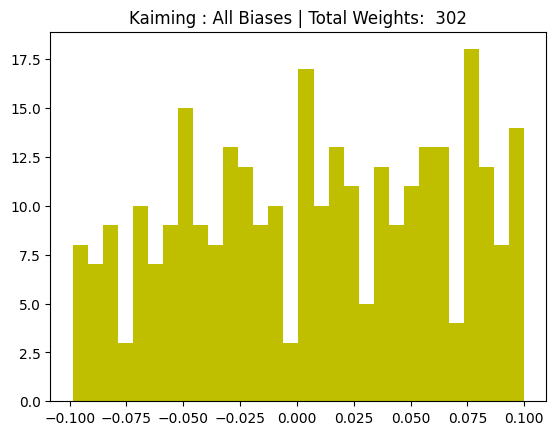

In [43]:
# Bias histogram. PyTorch initialises biases from the same bounded uniform, not
# from zero - though zero would be fine, since the weights already break symmetry.
plt.hist(all_biases,color='y',bins=30)
plt.title(f"Kaiming : All Biases | Total Weights:  {len(all_biases)}");

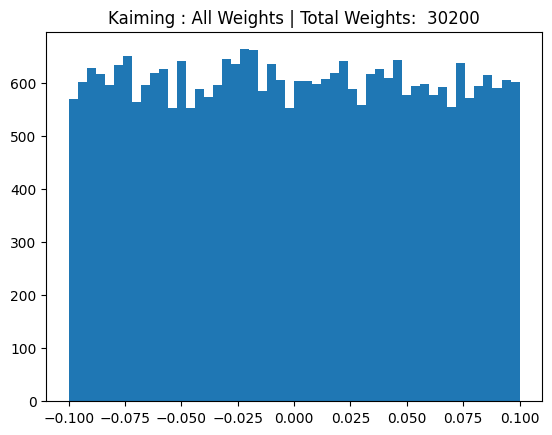

In [44]:
# Weight histogram: a bounded uniform, symmetric about zero. Note the hard edges
# - a normal distribution would have tails.
plt.hist(all_weights,bins=50)
plt.title(f'Kaiming : All Weights | Total Weights:  {len(all_weights)}');

In [45]:
# nn.Linear? shows the docstring, which states the default init:
# U(-sqrt(k), sqrt(k)) with k = 1/in_features.
nn.Linear?

In [46]:
len(all_weights), len(all_biases)

(30200, 302)

In [47]:
# A shape aside: rank-3 tensor indexing, unrelated to initialisation.
test_arr = torch.rand(5,3,5)

In [48]:
test_arr.shape

torch.Size([5, 3, 5])

In [49]:
test_arr

tensor([[[0.1169, 0.1218, 0.5001, 0.0349, 0.4961],
         [0.6679, 0.0859, 0.3483, 0.5148, 0.5491],
         [0.7029, 0.3011, 0.7632, 0.9453, 0.9738]],

        [[0.6740, 0.8343, 0.6892, 0.9992, 0.1938],
         [0.8118, 0.8195, 0.0721, 0.0687, 0.6577],
         [0.7407, 0.9299, 0.9094, 0.9126, 0.6462]],

        [[0.2796, 0.7528, 0.4492, 0.7247, 0.4502],
         [0.6501, 0.6631, 0.5720, 0.8276, 0.8936],
         [0.7280, 0.7146, 0.3004, 0.2850, 0.9346]],

        [[0.5195, 0.7054, 0.9358, 0.2540, 0.0634],
         [0.5731, 0.7591, 0.7490, 0.7354, 0.8090],
         [0.4203, 0.9289, 0.7158, 0.5288, 0.2100]],

        [[0.7305, 0.6522, 0.7408, 0.3532, 0.6418],
         [0.6461, 0.5041, 0.5829, 0.2278, 0.0210],
         [0.5060, 0.9377, 0.3416, 0.1113, 0.8757]]])

In [50]:
test_arr[4][1][0]

tensor(0.6461)

In [51]:
# The empirical check: k = sqrt(1/100) = 0.1 is the theoretical bound, and the
# observed min/max of a real layer should sit just inside it.
k = np.sqrt(1/100)

emperical_values = [np.min(model.fc1.weight.data.detach().numpy()), np.max(model.fc1.weight.data.detach().numpy())]

In [52]:
# Confirmed - PyTorch's default really is Kaiming-uniform scaled by fan-in.
# Because that default is ReLU-appropriate, explicit initialisation code is
# rarely needed in modern PyTorch.
print(k)
print(emperical_values)

print("\nThis proves PyTorch is using Kaming/He initialization as a defualt")

0.1
[np.float32(-0.09998387), np.float32(0.09997441)]

This proves PyTorch is using Kaming/He initialization as a defualt


## Now the Xavier Initialization

In [53]:
# Xavier normal instead: a Gaussian with variance 2/(fan_in + fan_out).
# Note the concatenate is outside the `if`, so biases are collected too - the
# histogram below mixes Xavier weights with default-initialised biases.
xavier_model = classfier()

all_weights = np.array([])

for pname, y in xavier_model.named_parameters():
  if 'weight' in pname:
    nn.init.xavier_normal_(y)

  all_weights = np.concatenate((all_weights, y.detach().flatten().numpy()), axis=0)

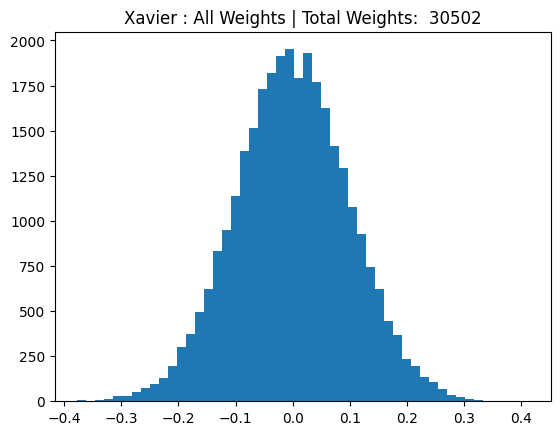

In [54]:
# The Xavier histogram: bell-shaped rather than flat-topped, because it is
# normal rather than uniform. Both are 'small random numbers scaled by layer
# size'; the difference between them matters far less than getting the SCALE
# right at all.
plt.hist(all_weights,bins=50)
plt.title(f'Xavier : All Weights | Total Weights:  {len(all_weights)}');